# OMPython

- free, open source, highly portable Python based interactive session handler for Modelica scripting

- provides the modeler with components for creating a complete Modelica modeling, compilation and simulation environment **based on the latest OpenModelica library standard available**

- OMPython is architectured to **combine both the solving strategy and model building**

- OMPython is **not a standalone package**, it depends upon the OpenModelica installation

- OMPython is implemented in Python and **depends on ZeroMQ - high performance asynchronous messaging library**

## OMPython Features

 - Interactive session handling, parsing, interpretation of commands and Modelica expressions for evaluation, simulation, plotting, etc.

 - Interface to the latest OpenModelica API calls.

 - Optimized parser results that give control over every element of the output.

 - Helper functions to allow manipulation on Nested dictionaries.

 - Easy access to the library and testing of OpenModelica commands.

## Enhanced OMPython Features

In [1]:
from pathlib import Path
from OMPython import ModelicaSystem

model_path = Path("/home/flo/repos/SystemSimulation/examples/Modelica/pendulum.mo")

pendulum = ModelicaSystem(str(model_path), "Pendulum")

pendulum.buildModel()

### Standard **Get**-Methods

In [2]:
pendulum.getQuantities()

[{'name': 'omega',
  'changeable': 'false',
  'description': None,
  'variability': 'continuous',
  'causality': 'local',
  'alias': 'noAlias',
  'aliasvariable': None,
  'start': None,
  'min': None,
  'max': None,
  'unit': None},
 {'name': 'theta',
  'changeable': 'false',
  'description': None,
  'variability': 'continuous',
  'causality': 'local',
  'alias': 'noAlias',
  'aliasvariable': None,
  'start': None,
  'min': None,
  'max': None,
  'unit': None},
 {'name': 'der(omega)',
  'changeable': 'false',
  'description': None,
  'variability': 'continuous',
  'causality': 'local',
  'alias': 'noAlias',
  'aliasvariable': None,
  'start': None,
  'min': None,
  'max': None,
  'unit': None},
 {'name': 'der(theta)',
  'changeable': 'false',
  'description': None,
  'variability': 'continuous',
  'causality': 'local',
  'alias': 'noAlias',
  'aliasvariable': None,
  'start': None,
  'min': None,
  'max': None,
  'unit': None},
 {'name': '$cse1',
  'changeable': 'false',
  'description

In [3]:
pendulum.getContinuous()

{'omega': None,
 'theta': None,
 'der(omega)': None,
 'der(theta)': None,
 '$cse1': None}

In [4]:
pendulum.getInputs()

{}

In [5]:
pendulum.getOutputs()

{}

In [6]:
pendulum.getParameters()

{'g': '9.81', 'l': '1.0', 'omega0': '0.0', 'theta0': '0.1'}

In [7]:
pendulum.getSimulationOptions()

{'startTime': '0',
 'stopTime': '10',
 'stepSize': '0.02',
 'tolerance': '1e-06',
 'solver': 'dassl',
 'outputFormat': 'mat'}

In [8]:
pendulum.getSolutions()

Error: Result file does not exist 


### Standard **Set**-Methods

In [9]:
#pendulum.setParameters("l=3.0")
pendulum.getParameters()

{'g': '9.81', 'l': '1.0', 'omega0': '0.0', 'theta0': '0.1'}

In [10]:
#pendulum.setSimulationOptions(["stopTime=6.5", "tolerance=5e-6", "solver=dassl"])
pendulum.getSimulationOptions()

{'startTime': '0',
 'stopTime': '10',
 'stepSize': '0.02',
 'tolerance': '1e-06',
 'solver': 'dassl',
 'outputFormat': 'mat'}

### Simulation

In [11]:
pendulum.simulate()

LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


In [12]:
pendulum.getSolutions()

('der(omega)',
 'der(theta)',
 'g',
 'l',
 'omega',
 'omega0',
 'theta',
 'theta0',
 'time')

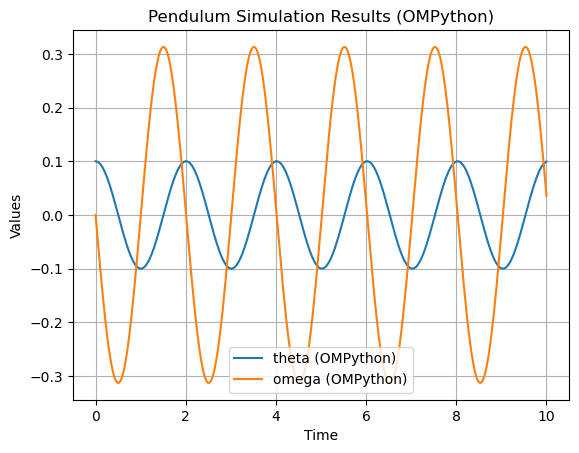

In [13]:
times_om, theta_om, omega_om = pendulum.getSolutions(["time", "theta", "omega"])

import matplotlib.pyplot as plt
plt.plot(times_om, theta_om, label='theta (OMPython)')
plt.plot(times_om, omega_om, label='omega (OMPython)')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Pendulum Simulation Results (OMPython)')
plt.legend()
plt.grid()
plt.show()

### Export as **FMU**

In [232]:
fmi_version = "2.0"
fmu_type = "me_cs"
fmu_path = pendulum.convertMo2Fmu(version=fmi_version, fmuType=fmu_type)
print(fmu_path)

/tmp/tmpyqbybgj6/Pendulum.fmu


In [ ]:
import shutil
shutil.move(fmu_path, "/home/flo/repos/SystemSimulation/examples/FMI/Pendulum.fmu")

'/home/flo/repos/SystemSimulation/examples/OMPython/MyLibrary/Pendulum.fmu'